In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = Path("/Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet")
sys.path.insert(0, str(ROOT / "python"))

import numpy as np
import astropy.units as u
import astropy.constants as const
import gammapy

#to check that this is consistent with the earlier version of just BHJet (though with the new wrapper)
import bhjet
from bhjet import BHJet, BLJet
from bhjet.gammapy import BHJetSpectralModel

In [ ]:
#for easily building bhjet so can quickly compare : 
def make_bljet_from_model(model):
    return BLJet(
        mass_bh=float(model.mass_bh.value),
        jet_power_eddington=float(model.jet_power_eddington.value),
        z_jet_launching=float(model.z_jet_launching.value),
        r_initial=float(model.r_initial.value),
        z_end_of_acceleration=float(model.z_end_of_acceleration.value),
        z_dissipation=float(model.z_dissipation.value),
        z_max_calculation=float(model.z_max_calculation.value),
        sigma_final=float(model.sigma_final.value),
        gamma_final=float(model.gamma_final.value),
        electron_temperature_jet_base=float(model.electron_temperature_jet_base.value),
        gamma_acceleration_exponent=float(model.gamma_acceleration_exponent.value),
        opening_angle_constant=float(model.opening_angle_constant.value),
        fraction_nonthermal_electrons=float(model.fraction_nonthermal_electrons.value),
        fraction_nonthermal_protons=float(model.fraction_nonthermal_protons.value),
        factor_break_electrons=float(model.factor_break_electrons.value),
        factor_break_protons=float(model.factor_break_protons.value),
        factor_max_energy_electrons=float(model.factor_max_energy_electrons.value),
        factor_max_energy_protons=float(model.factor_max_energy_protons.value),
        index_injected_electrons=float(model.index_injected_electrons.value),
        index_injected_protons=float(model.index_injected_protons.value),
        calc_pair_content_from_plasma_beta=False,
        plasma_beta_jet_base=float(model.plasma_beta_jet_base.value),
        dlgz=float(model.dlgz.value),
        verbosity_level=0,
        cutoff_type=int(model.cutoff_type.value),
    )

def make_bhjet_from_model(model):
    return BHJet(
        theta_obs=float(model.theta_obs.value),
        distance=float(model.distance.value),
        redshift=float(model.redshift.value),
        include_counterjet=True,
        compton_threshold=float(model.compton_threshold.value),
        profile_time=False,
        verbosity_level=0,
    )

In [ ]:
# complete parameter overview:  
# bljet = BLJet(
#     jet_power_eddington=1e-5, # in units of the Eddington Luminosity
#     r_initial=3, # in units of rg
#     z_end_of_acceleration=1e5, # in units of rg
#     z_dissipation=1e2, # in units of rg
#     sigma_final=1,
#     gamma_final=15, # Lorentz factor
#     plasma_beta_jet_base=0.2,
#     electron_temperature_jet_base=1e4, # keV
#     fraction_nonthermal_electrons=1e-1, 
#     fraction_nonthermal_protons=0.1, 
#     factor_break_electrons=1, 
#     factor_break_protons=1, 
#     factor_max_energy_electrons=1, 
#     factor_max_energy_protons=1, 
#     index_injected_electrons=2, 
#     z_max_calculation=1e6 # in units of rg
# )

# #never free parameters for jet dynamics class: 
# z_jet_launching=2 # in units of rg
# mass_bh=1e9, # M_sun
# gamma_acceleration_exponent=0.5
# opening_angle_constant=0.15
# dlgz=0.1
# verbosity_level=1

# #these are also never free for BHJet: 
# bhjet = BHJet(
#     theta_obs=17, # degree
#     distance=16e3, # kpc 
#     redshift=0.00428,
#     include_counterjet=True, 
#     compton_threshold=1e-5,
#     profile_time=True,
#     verbosity_level=1)
# bhjet.init_jet_dynamics(bljet)

In [ ]:
gammapy_model=BHJetSpectralModel()
gammapy_model

In [5]:
#this is using the same parameters to build a normal bhjet version for comparison
bhjet_dyn = make_bljet_from_model(gammapy_model)
bhjet_model = make_bhjet_from_model(gammapy_model) 
bhjet_model.init_jet_dynamics(bhjet_dyn)

In [6]:
E_eV = np.logspace(-8, 15, 200) * u.eV
energy_erg = E_eV.to_value(u.erg)

In [7]:
#gammapy result, externally will expect any astropy unit, internally will convert this to erg (in evaluate function)
dnde_gammapy_model_flux = gammapy_model(E_eV) # cm^-2 s^-1 erg^-1

#base bhjet model, which will interpret the energy input as erg (always)
#this returns flux in E dN/dE 
bhjet_model.compute_full_jet(photon_energy_grid=energy_erg.tolist()) #doesn't use the astropy unit formula at all
bhjet_flux_e_dnde = bhjet_model.get_observed_photon_flux_total()

#need to convert this energy_flux back to number flux to compare with gammapy flux out
bhjet_flux_dnde = bhjet_flux_e_dnde / energy_erg 

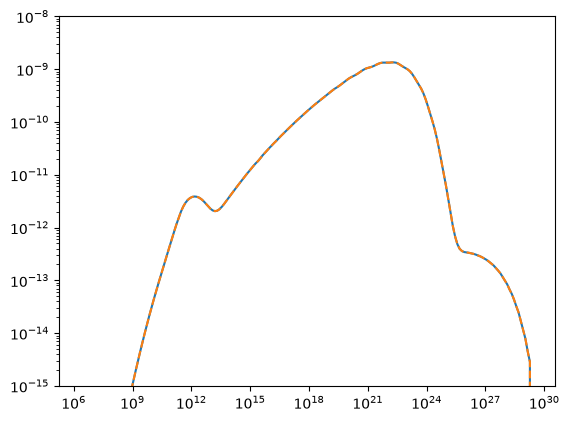

In [46]:
#convert to nu and F_nu: 
nu = E_eV.to(u.Hz, equivalencies=u.spectral())

#from dN/dE need to get F_nu = E dN/dE dE/dnu
gammapy_f_nu = (E_eV * dnde_gammapy_model_flux *const.h).to(u.erg/(u.cm**2 *u.s * u.Hz))
bhjet_f_nu = (bhjet_flux_e_dnde* u.Unit("cm-2 s-1") * const.h).to(u.erg/(u.cm**2 *u.s * u.Hz))

plt.loglog(nu, bhjet_f_nu*nu)
plt.loglog(nu, gammapy_f_nu*nu, linestyle = '--')
plt.ylim(1e-15, 1e-8)
plt.show()

### **Timing Check**

In [8]:
#with gammapy 
energy = np.logspace(-8, 19, 200) * u.eV
%timeit gammapy_model(energy)

1.85 s ± 12.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
#python wrapper only 
%timeit bhjet_model.compute_full_jet(photon_energy_grid=energy.to_value(u.erg).tolist())

1.83 s ± 2.71 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
#timing change with the size of the energy grid
for n in [20, 50, 100, 200, 500]:
    energy_test = np.logspace(-8, 19, n) * u.eV
    result = %timeit -o -n 1 -r 3 gammapy_model(energy_test)
    print(f"{n:4d} points: {result.best:.3f} s")

1.86 s ± 10.3 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
  20 points: 1.843 s
1.85 s ± 18.9 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
  50 points: 1.833 s
1.83 s ± 1.4 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
 100 points: 1.832 s
1.83 s ± 1.16 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
 200 points: 1.831 s
1.84 s ± 10.7 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
 500 points: 1.834 s


In [ ]:
#delta value for deciding how many zones to use 
for dlgz in [0.2, 0.1, 0.05]:
    gammapy_model.dlgz.value = dlgz
    result = %timeit -o -n 1 -r 3 gammapy_model(energy)
    print(f"dlgz={dlgz}: {result.best:.3f} s")

966 ms ± 969 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
dlgz=0.2: 0.965 s
1.83 s ± 1.04 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
dlgz=0.1: 1.832 s
3.67 s ± 4.49 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
dlgz=0.05: 3.664 s


In [ ]:
#predictive inverse compton threshold to check if it should be run
thresholds = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
timings = {}

for threshold in thresholds:
    gammapy_model.compton_threshold.value = threshold
    result = %timeit -o -n 1 -r 3 gammapy_model(energy)
    timings[threshold] = result.best
    print(f"{threshold:.0e}: {result.best:.3f} s")

392 ms ± 4.16 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
1e-02: 0.388 s
389 ms ± 981 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
1e-03: 0.388 s
681 ms ± 455 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
1e-04: 0.680 s
3.71 s ± 34.2 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
1e-05: 3.686 s
3.69 s ± 11.4 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
1e-06: 3.678 s
